In [1]:
import numpy as np
from monodromy.haar import expected_cost
from monodromy.render import _plot_coverage_set
from qiskit import QuantumCircuit
from qiskit.circuit import Parameter
from qiskit.circuit.library import (
    CXGate,
    RZXGate,
    SwapGate,
    UGate,
    UnitaryGate,
    XXPlusYYGate,
    iSwapGate,
)
from qiskit.circuit.random import random_circuit
from qiskit.quantum_info import Operator, average_gate_fidelity
from qiskit.quantum_info.random import random_unitary
from qiskit.synthesis.two_qubit import TwoQubitWeylDecomposition
from qiskit.transpiler import (
    InstructionProperties,
    PassManager,
    Target,
    generate_preset_pass_manager,
)
from qiskit.transpiler.passes import Optimize1qGatesDecomposition
from tqdm import tqdm
from weylchamber import c1c2c3

from gulps.gulps_decomposer import GulpsDecomposer
from gulps.synthesis_pass import GulpsDecompositionPass
from gulps.utils.invariants import GateInvariants
from gulps.utils.visualize import render_path

# from gulps.synthesis_plugin import GulpsSynthesisPlugin
from gulps.utils.logging_config import logger

logger.setLevel("DEBUG")

In [2]:
isa = [
    (iSwapGate().power(1 / 4), 1 / 4, "sqrt4iswap"),
]
gate_set, costs, names = zip(*isa)
decomposer = GulpsDecomposer(gate_set=gate_set, costs=costs, names=names)

In [3]:
import numpy as np

can_op = np.load("can_op.npy")
current_op = np.load("current_op.npy")

target_gate = UnitaryGate(can_op)
current_gate = UnitaryGate(current_op)

In [4]:
from gulps.utils.recover_equiv import recover_local_equivalence

print(average_gate_fidelity(Operator(target_gate), Operator(current_gate)))

k1, k2, k3, k4, gphase = recover_local_equivalence(target_gate, current_gate)
qc = QuantumCircuit(2, global_phase=gphase)
qc.append(UnitaryGate(k1), [0])
qc.append(UnitaryGate(k2), [1])
qc.append(current_gate, [0, 1])
qc.append(UnitaryGate(k3), [0])
qc.append(UnitaryGate(k4), [1])
print(average_gate_fidelity(Operator(target_gate), Operator(qc)))


[gulps.utils.recover_equiv] DEBUG: Detected (a,b,b) vs (a,b,-b) symmetry; inserting Pauli corrections.


0.24072040777330167
0.9999999999060151


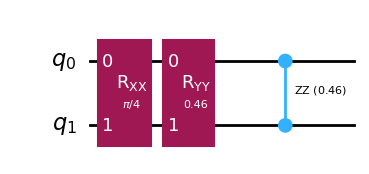

In [15]:
from qiskit import QuantumCircuit

qc = QuantumCircuit(2)
qc.rxx(0.7853981633974483, 0, 1)
qc.ryy(0.46023959276867954, 0, 1)
qc.rzz(0.46023959276867954, 0, 1)
qc.draw("mpl")

In [16]:
qc2 = QuantumCircuit(2)
qc2.rxx(0.7853981633974483, 0, 1)
qc2.ryy(0.46023959276867954, 0, 1)
qc2.rzz(-0.46023959276867954, 0, 1)

In [17]:
from gulps.utils.recover_equiv import recover_local_equivalence
from qiskit.quantum_info import Operator
from qiskit import QuantumCircuit
from qiskit.circuit.library import CXGate, CZGate, UnitaryGate
from qiskit.quantum_info import Operator, average_gate_fidelity

k1, k2, k3, k4, gphase = recover_local_equivalence(
    Operator(qc).data, Operator(qc2).data
)
qct = QuantumCircuit(2, global_phase=gphase)
qct.append(UnitaryGate(k1), [0])
qct.append(UnitaryGate(k2), [1])
qct.append(UnitaryGate(Operator(qc2)), [0, 1])
qct.append(UnitaryGate(k3), [0])
qct.append(UnitaryGate(k4), [1])
print(average_gate_fidelity(Operator(qc), Operator(qct)))


ValueError: Cannot recover local equivalence; Weyl differences [4.44089210e-16 2.22044605e-16 4.60239593e-01]